<a href="https://colab.research.google.com/github/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%203/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

**Phase 1: Bootstrapping Non-Parametric Uncertainty**

Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

In [15]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

Step 1.2: The Manual Bootstrap Engine

In [16]:
np.random.seed(42)

n_bootstrap = 10000
boot_medians = np.zeros(n_bootstrap)

for i in range(n_bootstrap):
  sample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
  boot_medians[i] = np.median(sample)

# 95% confidence interval
ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)

print("Observed median", np.median(driver_tips))
print("95% CI for median:", ci_lower, ci_upper)

Observed median 0.7553316913699188
95% CI for median: 0.2642554369019624 1.3635639228066991


**Phase 2: Falsification in Logistics A/B Testing**

Step 2.1: The Algorithmic Routing Crash

In [17]:
np.random.seed(42)

control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = np.mean(control) - np.mean(treatment)
print("Observed difference (Control - Treatment)", observed_diff)

Observed difference (Control - Treatment) 2.2649821306257394


Step 2.2: The Exact Non-Parametric Permutation

In [18]:
np.random.seed(42)

combined = np.concatenate([control, treatment])
n_perms = 5000
perm_diffs = np.zeros(n_perms)

for i in range(n_perms):
  shuffled = np.random.permutation(combined)
  perm_control = shuffled[:500]
  perm_treatment = shuffled[500:]
  perm_diffs[i] = np.mean(perm_control) - np.mean(perm_treatment)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("Observed difference:", observed_diff)
print("P-value:", p_value)

Observed difference: 2.2649821306257394
P-value: 0.0004


**Phase 3: Causal Control and the Mitigation of Selection Bias**

Step 3.1: The Loyalty Program Paradox

In [19]:
df = pd.read_csv("swiftcart_loyalty.csv")
print(df.head())
print(df.columns.tolist())

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227
['subscriber', 'pre_spend', 'account_age', 'support_tickets', 'post_spend']


In [20]:
# Naive Simple Difference in Means (SDO)
subscribers = df[df["subscriber"] == 1]["post_spend"]
non_subscribers = df[df["subscriber"] == 0]["post_spend"]

print("Mean spending (subscribers)", np.mean(subscribers))
print("Mean spending (non-subscribers)", np.mean(non_subscribers))

naive_sdo = np.mean(subscribers) - np.mean(non_subscribers)
print("Naive SDO:", naive_sdo)

Mean spending (subscribers) 74.04358604052543
Mean spending (non-subscribers) 56.47291665600164
Naive SDO: 17.57066938452379


Step 3.2: Propensity Score Matching (PSM) Architecture

In [21]:
from sklearn.linear_model import LogisticRegression

X = df[["pre_spend", "account_age", "support_tickets"]]
y = df["subscriber"]

model = LogisticRegression()
model.fit(X, y)

df["pscore"] = model.predict_proba(X)[:, 1]
print(df[["subscriber", "pscore"]].head(10))

   subscriber    pscore
0           1  0.546500
1           1  0.548460
2           1  0.683988
3           1  0.779637
4           1  0.397513
5           1  0.536750
6           1  0.827361
7           1  0.777491
8           1  0.294364
9           0  0.446673


In [22]:
from sklearn.neighbors import NearestNeighbors

treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["pscore"]])

distances, indices = nn.kneighbors(treated[["pscore"]])
matched_control = control.iloc[indices.flatten()]

In [23]:
att = np.mean(treated["post_spend"].values - matched_control["post_spend"].values)
print("ATT:", att)
print("Naive SDO:", naive_sdo)

ATT: 9.913855182824864
Naive SDO: 17.57066938452379


**Phase 4: AI Expansion (The Co-Pilot Era)**

Task 4.1: The "Love Plot" Visualization Directive

In [24]:
# Prepare df_unmatched and df_matched
df_unmatched = df.copy()

df_matched = pd.concat([treated.reset_index(drop=True),
                        matched_control.reset_index(drop=True)],
                       keys=["treated", "control"]).reset_index(level=0)
df_matched.rename(columns={"level_0": "group"}, inplace=True)

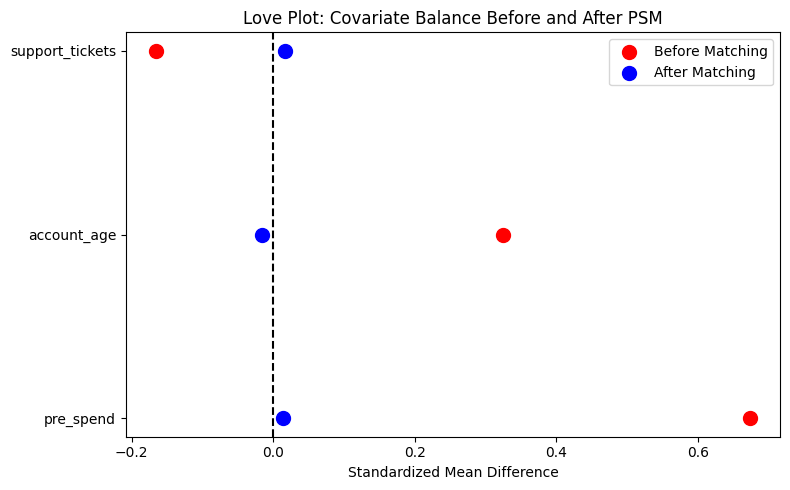

In [25]:
# Love Plot
covariates = ["pre_spend", "account_age", "support_tickets"]

smd_before = []
smd_after = []

for col in covariates:
    # Before matching
    t_mean = df_unmatched[df_unmatched["subscriber"] == 1][col].mean()
    c_mean = df_unmatched[df_unmatched["subscriber"] == 0][col].mean()
    t_std = df_unmatched[df_unmatched["subscriber"] == 1][col].std()
    c_std = df_unmatched[df_unmatched["subscriber"] == 0][col].std()
    pooled_std = np.sqrt((t_std**2 + c_std**2) / 2)
    smd_before.append((t_mean - c_mean) / pooled_std)

    # After matching
    t_mean_a = treated[col].mean()
    c_mean_a = matched_control[col].mean()
    t_std_a = treated[col].std()
    c_std_a = matched_control[col].std()
    pooled_std_a = np.sqrt((t_std_a**2 + c_std_a**2) / 2)
    smd_after.append((t_mean_a - c_mean_a) / pooled_std_a)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(covariates))

ax.scatter(smd_before, y_pos, color="red", label="Before Matching", s=100)
ax.scatter(smd_after, y_pos, color="blue", label="After Matching", s=100)
ax.axvline(x=0, color="black", linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(covariates)
ax.set_xlabel("Standardized Mean Difference")
ax.set_title("Love Plot: Covariate Balance Before and After PSM")
ax.legend()
plt.tight_layout()
plt.show()